# Introduction to scikit-learn

scikit-learn is a Python library with a consistent interface for many common machine-learning tasks. In this introduction, we will focus on the library's organizing ideas rather than on a catalog of models.

## Learning objective

By the end, you should be able to explain the roles of **features**, a **target**, an **estimator**, `fit`, and `predict` in a basic scikit-learn workflow.

## 1. Why scikit-learn?

A machine-learning project begins with a question and data. scikit-learn provides reusable tools for expressing a modeling approach in code. It works alongside other parts of the Python ecosystem: for example, NumPy helps represent numerical arrays, and pandas is often useful for tabular data.

The important idea for today is that scikit-learn emphasizes a **consistent workflow**. Learning a few shared actions will make later tools easier to approach.

In [1]:
import sklearn

print(f"scikit-learn version: {sklearn.__version__}")

scikit-learn version: 1.9.0


## 2. Estimators and a shared interface

In scikit-learn, an **estimator** is an object that represents a modeling approach. We create and configure the object first. Then we give it data through a common method called `fit`.

Once an estimator has been fitted, a prediction-oriented estimator can use `predict` to produce outputs for new inputs. Other scikit-learn objects may use a related method such as `transform`; the point is that the interface is deliberately regular.

In [2]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
print(model)

LinearRegression()


`model` is an estimator object. At this point it represents a choice of approach, but it has not learned from any observations.

## 3. Start with a learning problem

Before choosing an estimator, state what you want to predict. We separate the available inputs from the outcome of interest:

- $X$ contains the **features**: the input information available to the model.
- $y$ contains the **target**: the outcome we want to predict.

For a small illustration, suppose we want to use hours studied to predict a quiz score. The example is only meant to show the organization of data and code.

features X:
[[1.]
 [2.]
 [3.]
 [4.]
 [5.]]

target y:
[62. 68. 74. 81. 86.]


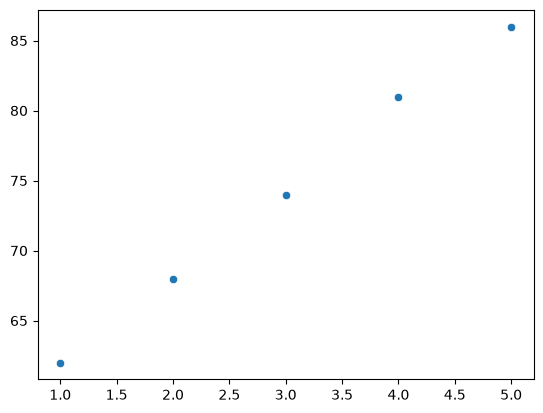

In [14]:
import numpy as np
import seaborn as sns

# Each row of X is one observation; each column is one feature.
X = np.array([[1.0], [2.0], [3.0], [4.0], [5.0]])
y = np.array([62.0, 68.0, 74.0, 81.0, 86.0])

print("features X:")
print(X)
print("\ntarget y:")
print(y)

sns.scatterplot(x=X.reshape(-1), y=y);

The shape of $X$ matters: scikit-learn expects a two-dimensional feature array $[n_\text{samples}, n_\text{features}]$, even when there is only one feature. Here, the rows correspond to observations and the single column records hours studied.

## 4. The big-picture workflow

This course will return to the workflow many times. For now, treat it as a roadmap:

1. State the learning problem.
2. Organize the features $X$ and target $y$.
3. Choose an estimator.
4. Fit the estimator to data.
5. Use the fitted estimator to make predictions.
6. Later in the course, study how to assess, refine, and compare models responsibly.

The rest of this notebook illustrates steps 3–5.

## 5. A minimal `fit` → `predict` example

We now recreate the small data set, create an estimator, and follow the basic pattern:

```python
model.fit(X, y)
predictions = model.predict(new_features)
```

The call to `fit` is where the estimator uses the observed input–output pairs. The call to `predict` then asks the fitted estimator for outputs associated with new feature values.

In [1]:
import numpy as np
from sklearn.linear_model import LinearRegression

X = np.array([[1.0], [2.0], [3.0], [4.0], [5.0]])
y = np.array([62.0, 68.0, 74.0, 81.0, 86.0])

model = LinearRegression()
model.fit(X, y)
print("The estimator has been fitted to the observed input–output pairs.")

The estimator has been fitted to the observed input–output pairs.


2.5 hours studied  →  predicted quiz score: 71.2
4.5 hours studied  →  predicted quiz score: 83.4


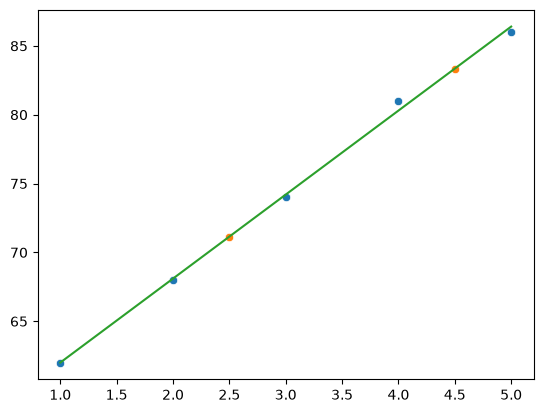

In [13]:
new_hours = np.array([[2.5], [4.5]])
predicted_scores = model.predict(new_hours)

line_points = model.predict(X[[0,4],:])

for hours, score in zip(new_hours.ravel(), predicted_scores):
    print(f"{hours:.1f} hours studied  →  predicted quiz score: {score:.1f}")

sns.scatterplot(x=X.reshape(-1), y=y, color="C0");
sns.scatterplot(x=new_hours.reshape(-1), y=predicted_scores, color="C1");
sns.lineplot(x=X.reshape(-1)[[0,4]], y=line_points, color="C2");

This example gives us a vocabulary and a code pattern. It does **not** yet tell us whether the predictions are reliable or whether this is an appropriate model for a real educational question. Those are important later questions.

## 6. Takeaway

scikit-learn is valuable because it provides a coherent, reusable language for machine-learning work. The key ideas from this first look are:

- begin with a well-defined learning problem;
- distinguish features $X$ from a target $y$;
- represent a modeling approach with an estimator;
- use `fit` to learn from observed data; and
- use `predict` to produce outputs for new inputs.

As we develop linear regression and later topics, we will return to this pattern and add the tools needed to use it carefully.